In [1]:
%pip install -q "gymnasium[atari]==1.2.0" "ale-py==0.11.2"

import random
import collections
import gc
import time
import re
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import ale_py
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation
import torch
import torch.nn as nn
import torch.optim as optim


SEED = 2
gym.register_envs(ale_py)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device, flush=True)


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class FireResetEnv(gym.Wrapper):
    """Preme FIRE all'avvio dell'episodio."""

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        obs, _, term, trunc, info = self.env.step(1)
        if term or trunc:
            obs, info = self.env.reset(**kwargs)
        return obs, info


class PongThreeActions(gym.ActionWrapper):
    """Espone soltanto NOOP (0), UP/RIGHT (2), DOWN/LEFT (3)."""

    def __init__(self, env):
        super().__init__(env)
        self.action_mapping = [0, 2, 3]
        self.action_space = gym.spaces.Discrete(3)

    def action(self, act):
        return self.action_mapping[int(act)]


class RallyRewardShaping(gym.Wrapper):
    """Aggiunge un bonus ai passi senza punto, limitato per singolo rally."""

    def __init__(self, env, step_bonus, max_rally_bonus):
        super().__init__(env)
        if step_bonus < 0.0:
            raise ValueError("step_bonus deve essere non negativo")
        if max_rally_bonus < 0.0:
            raise ValueError("max_rally_bonus deve essere non negativo")

        self.step_bonus = float(step_bonus)
        self.max_rally_bonus = float(max_rally_bonus)
        self.rally_steps = 0
        self.rally_bonus = 0.0

    def reset(self, **kwargs):
        self.rally_steps = 0
        self.rally_bonus = 0.0
        return self.env.reset(**kwargs)

    def step(self, action):
        obs, raw_reward, term, trunc, info = self.env.step(action)
        raw_reward = float(raw_reward)
        completed_rally_steps = None
        shaping_bonus = 0.0

        if raw_reward == 0.0 and not (term or trunc):
            self.rally_steps += 1
            remaining = max(0.0, self.max_rally_bonus - self.rally_bonus)
            shaping_bonus = min(self.step_bonus, remaining)
            self.rally_bonus += shaping_bonus
        else:
            if raw_reward != 0.0:
                completed_rally_steps = self.rally_steps
            self.rally_steps = 0
            self.rally_bonus = 0.0

        shaped_reward = raw_reward + shaping_bonus
        info = dict(info)
        info["raw_reward"] = raw_reward
        info["shaping_bonus"] = shaping_bonus
        info["rally_steps"] = self.rally_steps
        info["completed_rally_steps"] = completed_rally_steps
        return obs, shaped_reward, term, trunc, info


def make_env(step_bonus=0.0, max_rally_bonus=0.0):
    env = gym.make("ALE/Pong-v5", frameskip=1)
    env = AtariPreprocessing(
        env,
        noop_max=30,
        frame_skip=4,
        screen_size=84,
        terminal_on_life_loss=False,
        grayscale_obs=True,
        scale_obs=False,
    )
    env = FireResetEnv(env)
    env = PongThreeActions(env)

    if step_bonus > 0.0 and max_rally_bonus > 0.0:
        env = RallyRewardShaping(
            env,
            step_bonus=step_bonus,
            max_rally_bonus=max_rally_bonus,
        )

    return FrameStackObservation(env, stack_size=4)

Note: you may need to restart the kernel to use updated packages.
Dispositivo: cuda


In [2]:
class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        return self.net(x / 255.0)


class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, terminated):
        self.buffer.append(
            (
                np.array(state, dtype=np.uint8),
                action,
                reward,
                np.array(next_state, dtype=np.uint8),
                terminated,
            )
        )

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, terminated = zip(*batch)
        return (
            torch.tensor(np.array(state), dtype=torch.uint8, device=device).float(),
            torch.tensor(action, dtype=torch.int64, device=device),
            torch.tensor(reward, dtype=torch.float32, device=device),
            torch.tensor(np.array(next_state), dtype=torch.uint8, device=device).float(),
            torch.tensor(terminated, dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)


def evaluate(eval_env, model=None, episodes=20, base_seed=1000):
    """Valuta esclusivamente sul reward Atari originale."""
    scores = []
    for episode in range(episodes):
        state, _ = eval_env.reset(seed=base_seed + episode)
        if model is None:
            eval_env.action_space.seed(base_seed + episode)

        done = False
        total_raw_reward = 0.0
        while not done:
            if model is None:
                action = eval_env.action_space.sample()
            else:
                state_t = torch.tensor(
                    np.array(state), dtype=torch.uint8, device=device
                ).float().unsqueeze(0)
                with torch.no_grad():
                    action = model(state_t).argmax(dim=1).item()

            state, reward, term, trunc, _ = eval_env.step(action)
            done = term or trunc
            total_raw_reward += reward

        scores.append(total_raw_reward)

    return float(np.mean(scores)), float(np.std(scores))

In [3]:

BUFFER_CAPACITY = 100000
TOTAL_STEPS = 1800000
LEARNING_STARTS = 20000
TRAIN_FREQ = 4
EPS_START = 1.0
EPS_END = 0.01
DECAY_STEPS = 800000
GAMMA = 0.99
BATCH_SIZE = 64
LR = 1e-4
TARGET_UPDATE = 2000
CHECKPOINTS = [600000, 900000, 1200000, 1500000, 1800000]
EVAL_EPISODES = 20
HUMAN_BENCHMARK = 9.3


RALLY_BONUS_HORIZON = 100
SMALL_STEP_BONUS = 0.0002
MODERATE_STEP_BONUS = 0.001
AGGRESSIVE_STEP_BONUS = 0.005
SMALL_MAX_RALLY_BONUS = SMALL_STEP_BONUS * RALLY_BONUS_HORIZON
MODERATE_MAX_RALLY_BONUS = MODERATE_STEP_BONUS * RALLY_BONUS_HORIZON
AGGRESSIVE_MAX_RALLY_BONUS = AGGRESSIVE_STEP_BONUS * RALLY_BONUS_HORIZON

assert TOTAL_STEPS in CHECKPOINTS
assert 0 < SMALL_STEP_BONUS < MODERATE_STEP_BONUS < AGGRESSIVE_STEP_BONUS

In [4]:
def train_experiment(label, step_bonus, max_rally_bonus, seed=SEED):
    """Esegue una run completa e restituisce checkpoint e diagnostiche."""
    set_all_seeds(seed)
    train_env = make_env(step_bonus, max_rally_bonus)
    eval_env = make_env()
    train_env.action_space.seed(seed)
    eval_env.action_space.seed(seed + 1)

    n_actions = train_env.action_space.n
    policy_net = DQN(n_actions).to(device)
    target_net = DQN(n_actions).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=LR)
    loss_fn = nn.SmoothL1Loss()
    replay_buffer = ReplayBuffer(capacity=BUFFER_CAPACITY)

    state, _ = train_env.reset(seed=seed)
    raw_ep_reward = 0.0
    shaped_ep_reward = 0.0
    ep_bonus = 0.0
    current_rally_lengths = []

    history = {
        "step": [],
        "raw_return": [],
        "shaped_return": [],
        "bonus": [],
        "mean_rally": [],
        "loss": [],
    }
    checkpoint_results = {}

    policy_net.train()
    start_time = time.time()
    print(
        f"\n=== {label}: bonus={step_bonus:g}, cap={max_rally_bonus:.2f} ===",
        flush=True,
    )

    for step in range(1, TOTAL_STEPS + 1):
        epsilon = max(
            EPS_END,
            EPS_START - (EPS_START - EPS_END) * (step / DECAY_STEPS),
        )

        if random.random() < epsilon:
            action = train_env.action_space.sample()
        else:
            state_t = torch.tensor(
                np.array(state), dtype=torch.uint8, device=device
            ).float().unsqueeze(0)
            with torch.no_grad():
                action = policy_net(state_t).argmax(dim=1).item()

        next_state, shaped_reward, term, trunc, info = train_env.step(action)
        raw_reward = info["raw_reward"]
        shaping_bonus = info["shaping_bonus"]
        completed_rally_steps = info["completed_rally_steps"]


        replay_buffer.push(state, action, shaped_reward, next_state, term)
        state = next_state
        raw_ep_reward += raw_reward
        shaped_ep_reward += shaped_reward
        ep_bonus += shaping_bonus

        if completed_rally_steps is not None:
            current_rally_lengths.append(completed_rally_steps)

        if term or trunc:
            history["step"].append(step)
            history["raw_return"].append(raw_ep_reward)
            history["shaped_return"].append(shaped_ep_reward)
            history["bonus"].append(ep_bonus)
            history["mean_rally"].append(
                float(np.mean(current_rally_lengths))
                if current_rally_lengths
                else 0.0
            )

            if len(history["raw_return"]) % 20 == 0:
                elapsed = (time.time() - start_time) / 60.0
                print(
                    f"{label} | step {step:7d}/{TOTAL_STEPS} | "
                    f"ep {len(history['raw_return']):4d} | "
                    f"raw20 {np.mean(history['raw_return'][-20:]):6.2f} | "
                    f"shaped20 {np.mean(history['shaped_return'][-20:]):6.2f} | "
                    f"bonus20 {np.mean(history['bonus'][-20:]):6.2f} | "
                    f"rally20 {np.mean(history['mean_rally'][-20:]):6.1f} | "
                    f"eps {epsilon:.3f} | {elapsed:.1f}m",
                    flush=True,
                )

            state, _ = train_env.reset()
            raw_ep_reward = 0.0
            shaped_ep_reward = 0.0
            ep_bonus = 0.0
            current_rally_lengths = []

        if step > LEARNING_STARTS and step % TRAIN_FREQ == 0:
            b_s, b_a, b_r, b_ns, b_terminated = replay_buffer.sample(BATCH_SIZE)

            with torch.no_grad():
                max_next_q = target_net(b_ns).max(dim=1).values
                target_q = b_r + (1.0 - b_terminated) * GAMMA * max_next_q

            current_q = policy_net(b_s).gather(1, b_a.unsqueeze(1)).squeeze(1)
            loss = loss_fn(current_q, target_q)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
            optimizer.step()
            history["loss"].append(loss.item())

        if step % TARGET_UPDATE == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if step % 100000 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if step in CHECKPOINTS:
            policy_net.eval()
            mean_score, std_score = evaluate(
                eval_env,
                model=policy_net,
                episodes=EVAL_EPISODES,
            )
            policy_net.train()
            checkpoint_results[step] = (mean_score, std_score)
            print(
                f"--- {label} @ {step}: Atari raw "
                f"{mean_score:.2f} +/- {std_score:.2f} ---",
                flush=True,
            )

            safe_label = re.sub(r"[^a-z0-9]+", "_", label.lower()).strip("_")
            torch.save(
                {
                    "step": step,
                    "label": label,
                    "policy_state_dict": policy_net.state_dict(),
                    "target_state_dict": target_net.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "rally_step_bonus": step_bonus,
                    "max_rally_bonus": max_rally_bonus,
                },
                f"dqn_pong_{safe_label}_{step}.pth",
            )

    train_env.close()
    eval_env.close()

    result = {
        "label": label,
        "step_bonus": step_bonus,
        "max_rally_bonus": max_rally_bonus,
        "checkpoints": checkpoint_results,
        "history": history,
    }


    del replay_buffer, policy_net, target_net, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

In [5]:
small_run = train_experiment(
    label="Reward piccolo",
    step_bonus=SMALL_STEP_BONUS,
    max_rally_bonus=SMALL_MAX_RALLY_BONUS,
)

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]



=== Reward piccolo: bonus=0.0002, cap=0.02 ===
Reward piccolo | step   19521/1800000 | ep   20 | raw20 -20.60 | shaped20 -20.42 | bonus20   0.18 | rally20   44.5 | eps 0.976 | 0.4m
Reward piccolo | step   38264/1800000 | ep   40 | raw20 -20.70 | shaped20 -20.52 | bonus20   0.18 | rally20   42.9 | eps 0.953 | 1.4m
Reward piccolo | step   58584/1800000 | ep   60 | raw20 -20.75 | shaped20 -20.56 | bonus20   0.19 | rally20   46.8 | eps 0.928 | 2.5m
Reward piccolo | step   77791/1800000 | ep   80 | raw20 -20.55 | shaped20 -20.37 | bonus20   0.18 | rally20   43.7 | eps 0.904 | 3.6m
Reward piccolo | step   97977/1800000 | ep  100 | raw20 -20.70 | shaped20 -20.51 | bonus20   0.19 | rally20   46.4 | eps 0.879 | 4.7m
Reward piccolo | step  118370/1800000 | ep  120 | raw20 -20.35 | shaped20 -20.16 | bonus20   0.19 | rally20   46.0 | eps 0.854 | 5.9m
Reward piccolo | step  142339/1800000 | ep  140 | raw20 -19.85 | shaped20 -19.63 | bonus20   0.22 | rally20   53.0 | eps 0.824 | 7.3m
Reward piccolo

In [6]:
moderate_run = train_experiment(
    label="Reward moderato",
    step_bonus=MODERATE_STEP_BONUS,
    max_rally_bonus=MODERATE_MAX_RALLY_BONUS,
)


=== Reward moderato: bonus=0.001, cap=0.10 ===
Reward moderato | step   19521/1800000 | ep   20 | raw20 -20.60 | shaped20 -19.69 | bonus20   0.91 | rally20   44.5 | eps 0.976 | 0.4m
Reward moderato | step   38475/1800000 | ep   40 | raw20 -20.65 | shaped20 -19.75 | bonus20   0.90 | rally20   43.3 | eps 0.952 | 1.4m
Reward moderato | step   58626/1800000 | ep   60 | raw20 -20.15 | shaped20 -19.18 | bonus20   0.97 | rally20   45.0 | eps 0.927 | 2.6m
Reward moderato | step   78333/1800000 | ep   80 | raw20 -20.35 | shaped20 -19.41 | bonus20   0.94 | rally20   44.4 | eps 0.903 | 3.7m
Reward moderato | step   99557/1800000 | ep  100 | raw20 -20.25 | shaped20 -19.25 | bonus20   1.00 | rally20   47.7 | eps 0.877 | 4.9m
Reward moderato | step  120748/1800000 | ep  120 | raw20 -20.50 | shaped20 -19.50 | bonus20   1.00 | rally20   48.2 | eps 0.851 | 6.0m
Reward moderato | step  142932/1800000 | ep  140 | raw20 -20.60 | shaped20 -19.55 | bonus20   1.05 | rally20   50.7 | eps 0.823 | 7.1m
Reward 

In [7]:
aggressive_run = train_experiment(
    label=f"Reward aggressivo (cap {AGGRESSIVE_MAX_RALLY_BONUS:.2f})",
    step_bonus=AGGRESSIVE_STEP_BONUS,
    max_rally_bonus=AGGRESSIVE_MAX_RALLY_BONUS,
)


=== Reward aggressivo (cap 0.50): bonus=0.005, cap=0.50 ===
Reward aggressivo (cap 0.50) | step   19521/1800000 | ep   20 | raw20 -20.60 | shaped20 -16.03 | bonus20   4.57 | rally20   44.5 | eps 0.976 | 0.4m
Reward aggressivo (cap 0.50) | step   38496/1800000 | ep   40 | raw20 -20.70 | shaped20 -16.14 | bonus20   4.56 | rally20   43.5 | eps 0.952 | 1.3m
Reward aggressivo (cap 0.50) | step   58539/1800000 | ep   60 | raw20 -20.30 | shaped20 -15.50 | bonus20   4.80 | rally20   45.1 | eps 0.928 | 2.4m
Reward aggressivo (cap 0.50) | step   77749/1800000 | ep   80 | raw20 -20.55 | shaped20 -15.96 | bonus20   4.59 | rally20   43.7 | eps 0.904 | 3.3m
Reward aggressivo (cap 0.50) | step   97404/1800000 | ep  100 | raw20 -20.50 | shaped20 -15.83 | bonus20   4.67 | rally20   44.7 | eps 0.879 | 4.4m
Reward aggressivo (cap 0.50) | step  116906/1800000 | ep  120 | raw20 -20.40 | shaped20 -15.71 | bonus20   4.69 | rally20   44.1 | eps 0.855 | 5.4m
Reward aggressivo (cap 0.50) | step  136409/1800000

In [8]:
def tail_mean(run, key, n=100):
    values = run["history"][key]
    return float(np.mean(values[-n:])) if values else float("nan")

RUNS = [("small", small_run), ("moderate", moderate_run), ("aggressive", aggressive_run)]
print("CONFRONTO SUL REWARD ATARI ORIGINALE (media +/- std su 20 episodi)")
print(" step | piccolo | moderato | aggressivo | moderato-piccolo | aggressivo-piccolo")
for checkpoint in CHECKPOINTS:
    means = [run["checkpoints"][checkpoint][0] for _, run in RUNS]
    scores = [f"{run['checkpoints'][checkpoint][0]:6.2f} +/- {run['checkpoints'][checkpoint][1]:5.2f}" for _, run in RUNS]
    print(f"{checkpoint // 1000:4d}k | " + " | ".join(scores)
          + f" | {means[1]-means[0]:+6.2f} | {means[2]-means[0]:+6.2f}")
print("\nDIAGNOSTICA ULTIMI 100 EPISODI DI TRAINING")
for _, run in RUNS:
    print(f"{run['label']}: raw={tail_mean(run, 'raw_return'):.2f}, "
          f"shaped={tail_mean(run, 'shaped_return'):.2f}, "
          f"bonus={tail_mean(run, 'bonus'):.2f}, "
          f"rally medio={tail_mean(run, 'mean_rally'):.1f}")

CONFRONTO SUL REWARD ATARI ORIGINALE (media +/- std su 20 episodi)
 step | piccolo | moderato | aggressivo | moderato-piccolo | aggressivo-piccolo
 600k | -10.60 +/-  3.07 | -10.10 +/-  3.74 | -21.00 +/-  0.00 |  +0.50 | -10.40
 900k |  -3.50 +/-  5.89 |   6.30 +/-  8.01 | -21.00 +/-  0.00 |  +9.80 | -17.50
1200k |  -1.95 +/-  6.11 |   2.25 +/-  8.56 | -21.00 +/-  0.00 |  +4.20 | -19.05
1500k |  11.90 +/-  3.92 |  14.20 +/-  4.39 | -21.00 +/-  0.00 |  +2.30 | -32.90
1800k |  12.15 +/-  5.30 |  15.15 +/-  3.54 | -21.00 +/-  0.00 |  +3.00 | -33.15

DIAGNOSTICA ULTIMI 100 EPISODI DI TRAINING
Reward piccolo: raw=7.03, shaped=7.63, bonus=0.60, rally medio=197.5
Reward moderato: raw=12.82, shaped=15.47, bonus=2.65, rally medio=169.4
Reward aggressivo (cap 0.50): raw=-20.99, shaped=-17.10, bonus=3.89, rally medio=37.2


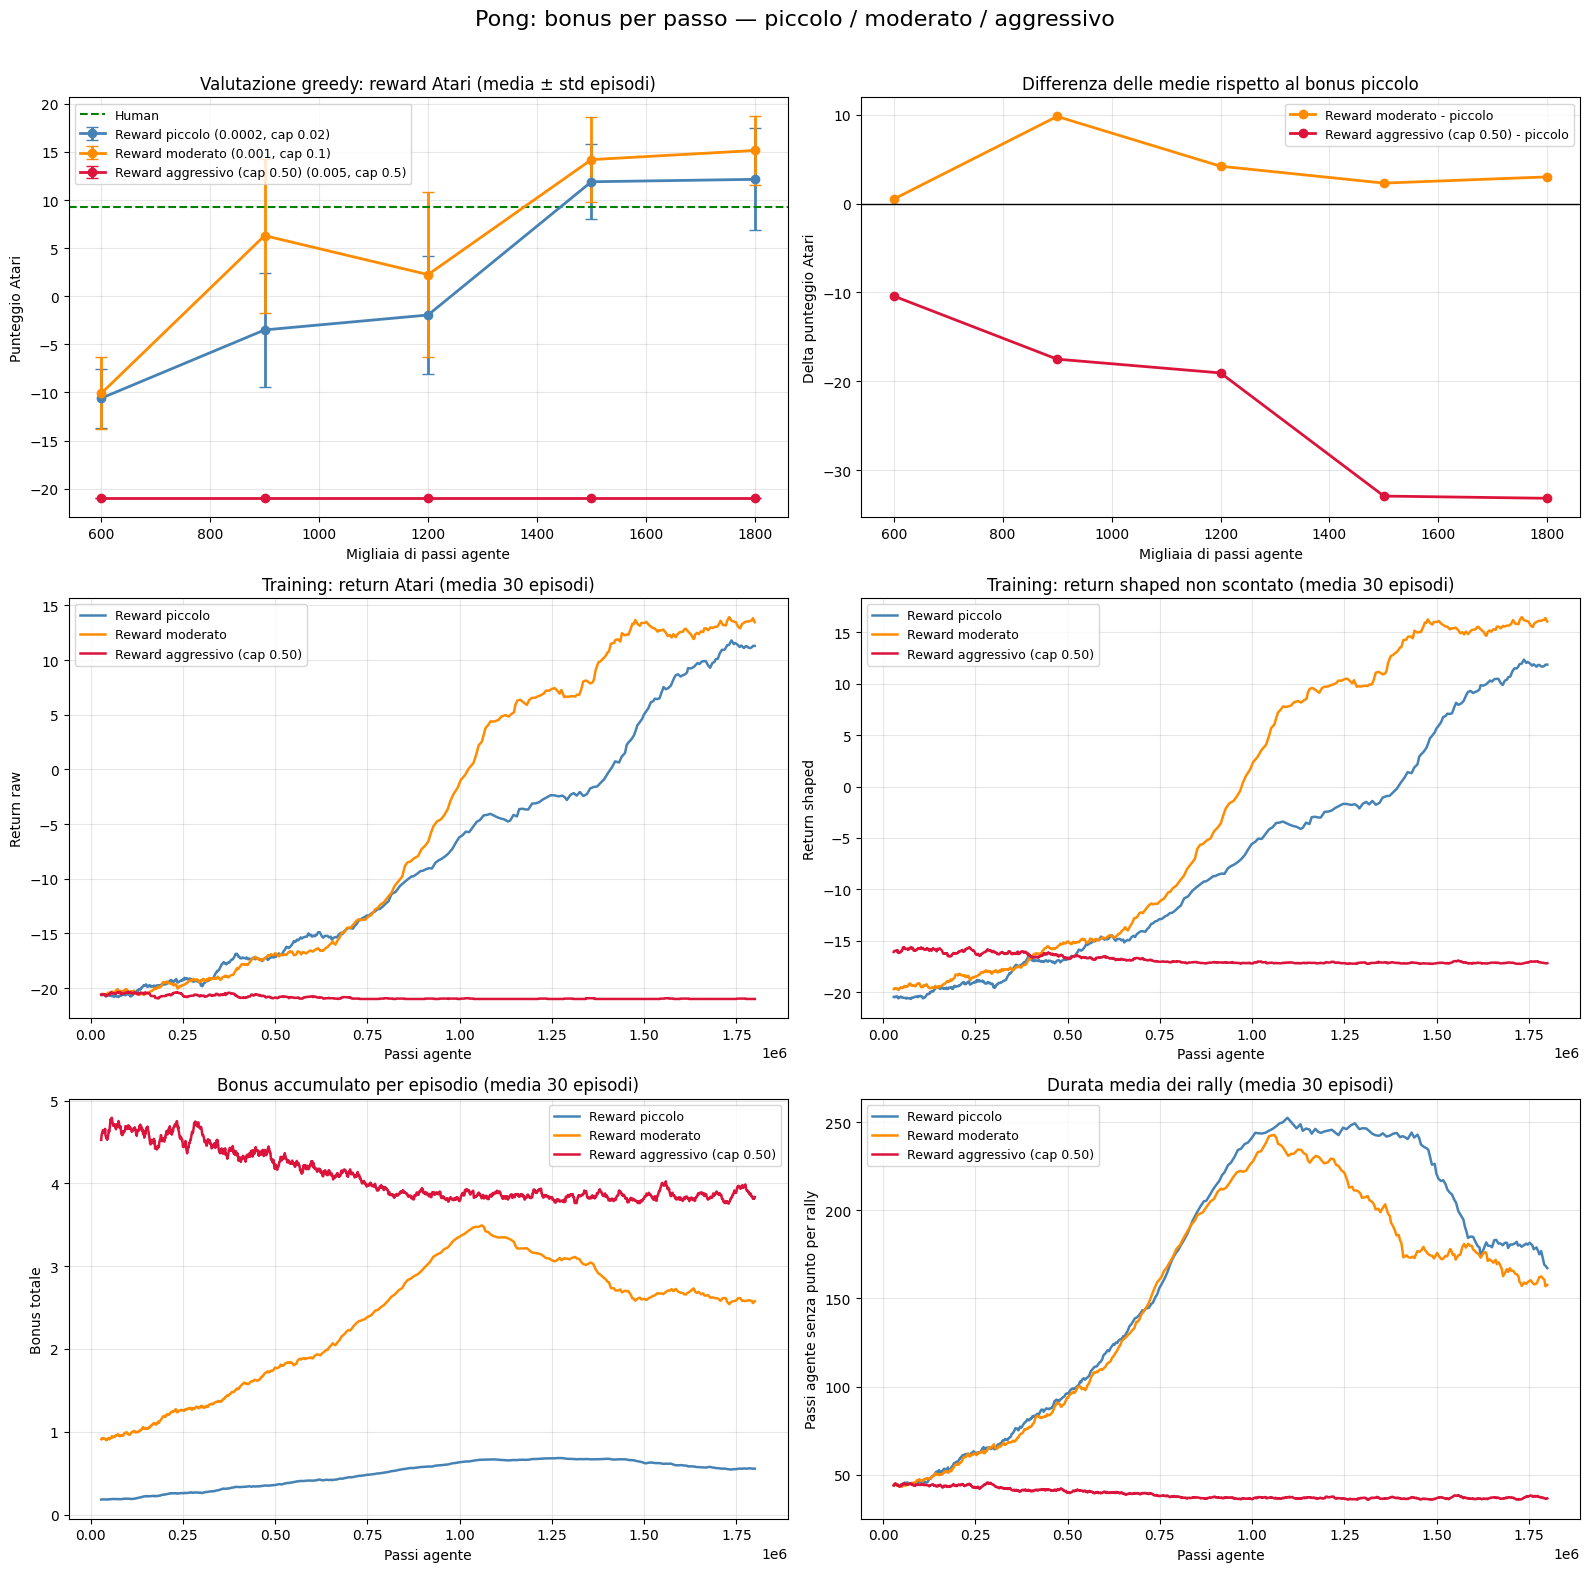

In [9]:
COLORS = {"small": "steelblue", "moderate": "darkorange", "aggressive": "crimson"}
RUNS = [("small", small_run), ("moderate", moderate_run), ("aggressive", aggressive_run)]

def rolling_xy(run, key, window=30):
    values = np.asarray(run["history"][key], dtype=float)
    steps = np.asarray(run["history"]["step"], dtype=float)
    if len(values) < window:
        return np.array([]), np.array([])
    return steps[window-1:], np.convolve(values, np.ones(window)/window, mode="valid")

checkpoint_k = np.asarray(CHECKPOINTS) / 1000.0
small_scores = np.asarray([small_run["checkpoints"][s][0] for s in CHECKPOINTS])
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
ax_eval, ax_delta, ax_raw, ax_shaped, ax_diagnostic, ax_rally = axes.ravel()
for key, run in RUNS:
    color = COLORS[key]
    scores = np.asarray([run["checkpoints"][s][0] for s in CHECKPOINTS])
    std = np.asarray([run["checkpoints"][s][1] for s in CHECKPOINTS])
    legend_label = f"{run['label']} ({run['step_bonus']:g}, cap {run['max_rally_bonus']:g})"
    ax_eval.errorbar(checkpoint_k, scores, yerr=std, marker="o", capsize=4,
                     linewidth=2, color=color, label=legend_label)
    if key != "small":
        ax_delta.plot(checkpoint_k, scores-small_scores, marker="o", linewidth=2,
                      color=color, label=run["label"] + " - piccolo")
    for ax, metric in ((ax_raw, "raw_return"), (ax_shaped, "shaped_return"),
                       (ax_diagnostic, "bonus"), (ax_rally, "mean_rally")):
        x, y = rolling_xy(run, metric)
        ax.plot(x, y, color=color, linewidth=1.8, label=run["label"])

ax_eval.axhline(HUMAN_BENCHMARK, color="green", linestyle="--", label="Human")
ax_eval.set(title="Valutazione greedy: reward Atari (media ± std episodi)",
            xlabel="Migliaia di passi agente", ylabel="Punteggio Atari")
ax_delta.axhline(0, color="black", linewidth=1)
ax_delta.set(title="Differenza delle medie rispetto al bonus piccolo",
             xlabel="Migliaia di passi agente", ylabel="Delta punteggio Atari")
ax_raw.set(title="Training: return Atari (media 30 episodi)", ylabel="Return raw")
ax_shaped.set(title="Training: return shaped non scontato (media 30 episodi)", ylabel="Return shaped")
ax_diagnostic.set(title="Bonus accumulato per episodio (media 30 episodi)", ylabel="Bonus totale")
ax_rally.set(title="Durata media dei rally (media 30 episodi)", ylabel="Passi agente senza punto per rally")
for ax in (ax_raw, ax_shaped, ax_diagnostic, ax_rally):
    ax.set_xlabel("Passi agente")
for ax in axes.ravel():
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle("Pong: bonus per passo — piccolo / moderato / aggressivo", fontsize=16)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.savefig("confronto_weights_reward_pong.png", dpi=160, bbox_inches="tight")
plt.show()